# Rozpoznawanie kółka i krzyżyka za pomocą filtrów krawędziowych

## Cel projektu

W tym notatniku poznamy metodę klasyfikacji prostych symboli graficznych — **krzyżyków (X)** i **kółek (O)** — bez użycia sieci neuronowych.

Kluczowa obserwacja:
- **Krzyżyk** zbudowany jest z linii ukośnych i pionowych → silnie reaguje na filtry krawędziowe w określonych kierunkach.
- **Kółko** ma symetryczną, izotropową strukturę → reaguje podobnie na filtry we wszystkich kierunkach.

Jeśli więc zastosujemy kilka filtrów krawędziowych w różnych orientacjach i porównamy liczbę białych pikseli po konwolucji, **wariancja tych wartości** będzie wyraźnie różna dla obu klas.

### Schemat procesu

```
Obrazy wejściowe
      ↓
  Normalizacja (512×512, skala szarości, binaryzacja, inwersja)
      ↓
  4 filtry krawędziowe (konwolucja)
      ↓
  Zliczanie białych pikseli po każdym filtrze
      ↓
  Wariancja odpowiedzi na 4 filtry
      ↓
  Średnia wariancja po klasie → metryka klasyfikacji
```

## 1. Importowanie bibliotek

Projekt korzysta z czterech głównych bibliotek:

| Biblioteka | Rola |
|---|---|
| `cv2` (OpenCV) | Wczytywanie obrazów, konwersja kolorów, binaryzacja, konwolucja |
| `matplotlib` | Wyświetlanie siatek obrazów w notatniku |
| `numpy` | Reprezentacja macierzy filtrów, obliczenia numeryczne |
| `math`, `os` | Pomocnicze operacje matematyczne i plikowe |

> **Instalacja:** jeśli biblioteki nie są zainstalowane, uruchom: `pip install opencv-python matplotlib numpy`

In [2]:
import cv2 as cv          # pip install opencv-python
from matplotlib import pyplot as pl
import numpy as np
import math
import os

# Ustawienie katalogu roboczego na katalog notatnika
# (zakładamy, że notatnik uruchamiamy z katalogu OpenCV)

notebook_dir = os.path.dirname(os.path.abspath("xo_notatnik.ipynb"))
if os.path.isdir(os.path.join(notebook_dir, "train_xo")):
    os.chdir(notebook_dir)
else:
    # Fallback: spróbuj ścieżki bezwzględnej
    os.chdir(r"d:\Source\ZSME\Resources\Python\OpenCV")

print("Katalog roboczy:", os.getcwd())
print(f"OpenCV: {cv.__version__}")
print(f"NumPy:  {np.__version__}")

Katalog roboczy: d:\Source\ZSME\Resources\Python\OpenCV
OpenCV: 4.13.0
NumPy:  2.4.4


## 2. Ładowanie obrazów treningowych

Dane wejściowe znajdują się w katalogu `train_xo/`. Zawiera on 10 obrazów:
- `k1.png` – `k5.png` → krzyżyki (klasa **K**)
- `o1.png` – `o5.png` → kółka (klasa **O**)

**Funkcja `ListImages()`** skanuje katalog i zwraca listę nazw plików o rozszerzeniach graficznych (`.jpg`, `.jpeg`, `.png`, `.bmp`).

Obrazy wczytujemy funkcją `cv2.imread()`, która zwraca tablicę NumPy w formacie BGR (Blue-Green-Red).

In [3]:
def ListImages(path, extensions=['.jpg', '.jpeg', '.png', '.bmp']):
    """Zwraca listę nazw plików graficznych z podanego katalogu."""
    ret = []
    for file_name in os.listdir(path):
        if os.path.splitext(file_name)[1].lower() in extensions:
            ret.append(file_name)
    return ret

path = "train_xo"
imageFiles = ListImages(path)

# Wczytanie obrazów krzyżyków (prefiks 'k') i kółek (prefiks 'o')
train_k = [cv.imread(f"{path}/{file}") for file in imageFiles if file.startswith('k')]
train_o = [cv.imread(f"{path}/{file}") for file in imageFiles if file.startswith('o')]

print(f"Wczytano {len(train_k)} obrazów krzyżyków: {[f for f in imageFiles if f.startswith('k')]}")
print(f"Wczytano {len(train_o)} obrazów kółek:    {[f for f in imageFiles if f.startswith('o')]}")
print(f"\nRozmiar pierwszego obrazu krzyżyka: {train_k[0].shape}  (wysokość × szerokość × kanały BGR)")

Wczytano 5 obrazów krzyżyków: ['k1.png', 'k2.png', 'k3.png', 'k4.png', 'k5.png']
Wczytano 5 obrazów kółek:    ['o1.png', 'o2.png', 'o3.png', 'o4.png', 'o5.png']

Rozmiar pierwszego obrazu krzyżyka: (300, 300, 3)  (wysokość × szerokość × kanały BGR)


## 3. Wizualizacja obrazów wejściowych

Zanim zaczniemy przetwarzanie, wyświetlamy surowe obrazy treningowe.

**Uwaga:** OpenCV wczytuje obrazy w formacie **BGR**, a matplotlib oczekuje **RGB** — dlatego przed wyświetleniem wykonujemy konwersję `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`.

**Funkcja `PlotImageList()`** przyjmuje listę obrazów i wyświetla je w siatce:
- `limit` — liczba kolumn siatki,
- `titles` — opcjonalne tytuły pod każdym obrazem,
- `figsize` — rozmiar całej figury w calach.

=== Krzyżyki (oryginalne) ===


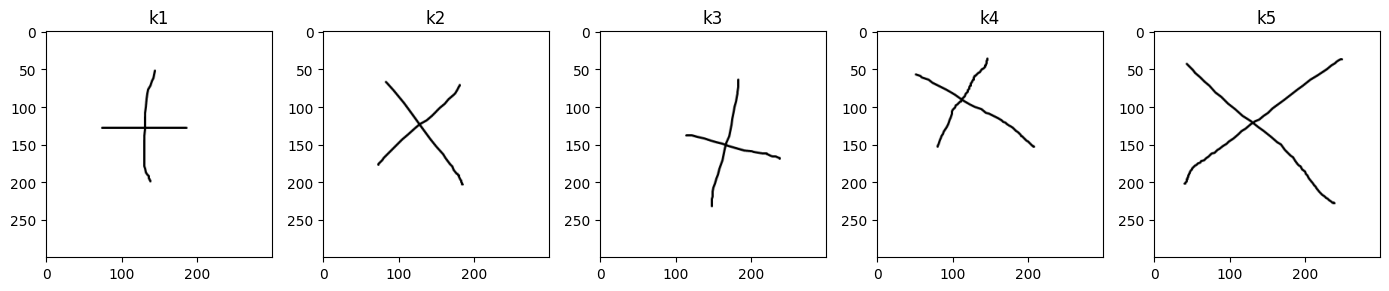

=== Kółka (oryginalne) ===


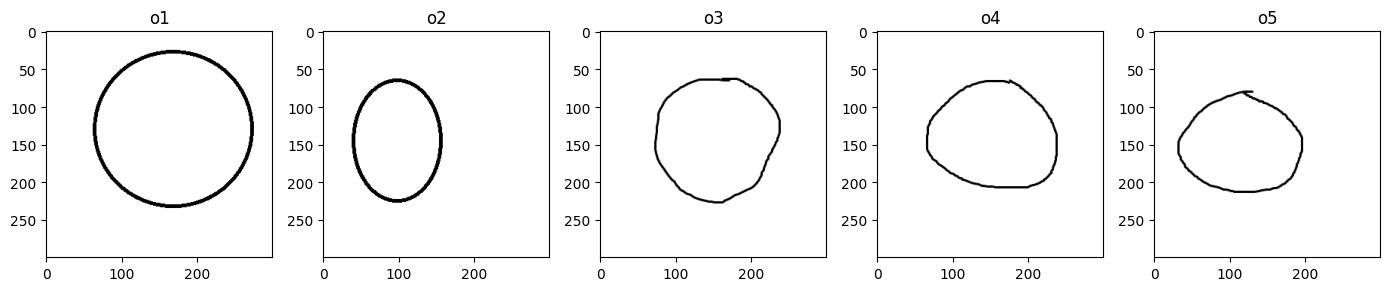

In [4]:
def PlotImageList(imgList, limit=2, titles=[], figsize=(8, 8)):
    """Wyświetla listę obrazów w siatce limit×n."""
    if not isinstance(imgList, list):
        raise ValueError("Input is not a list.")
    if not imgList:
        raise ValueError("List is empty.")

    nCount = len(imgList)
    h = min(nCount, limit)
    v = math.ceil(nCount / limit)

    _, axes = pl.subplots(v, h, figsize=figsize)
    axes = axes.flatten() if nCount > 1 else [axes]

    for i, ax in enumerate(axes):
        if i < nCount:
            ax.imshow(cv.cvtColor(imgList[i], cv.COLOR_BGR2RGB))
            if i < len(titles):
                ax.set_title(titles[i])
            ax.axis('on')
        else:
            ax.axis('off')

    pl.tight_layout()
    pl.show()

# Wyświetlenie oryginalnych obrazów treningowych
print("=== Krzyżyki (oryginalne) ===")
PlotImageList(train_k, limit=5,
              titles=[f"k{i+1}" for i in range(len(train_k))],
              figsize=(14, 4))

print("=== Kółka (oryginalne) ===")
PlotImageList(train_o, limit=5,
              titles=[f"o{i+1}" for i in range(len(train_o))],
              figsize=(14, 4))

## 4. Normalizacja obrazów

Aby móc porównywać obrazy niezależnie od ich oryginalnego rozmiaru i kolorystyki, każdy obraz jest **normalizowany** do postaci standardowej.

### Kroki normalizacji

| Krok | Operacja | Efekt |
|---|---|---|
| 1 | `cv2.resize(img, (512, 512))` | Ujednolicenie rozmiaru |
| 2 | `cv2.cvtColor(..., COLOR_BGR2GRAY)` | Konwersja do skali szarości (1 kanał) |
| 3 | `cv2.threshold(..., 127, 255, THRESH_BINARY)` | Binaryzacja: każdy piksel → 0 lub 255 |
| 4 | `cv2.bitwise_not(...)` | Inwersja: symbol staje się **biały** na czarnym tle |

Po inwersji **białe piksele = kontur symbolu**. Suma białych pikseli podzielona przez 255 daje ich liczbę.

$$\text{liczba białych pikseli} = \frac{\sum_{i,j} I(i,j)}{255}$$

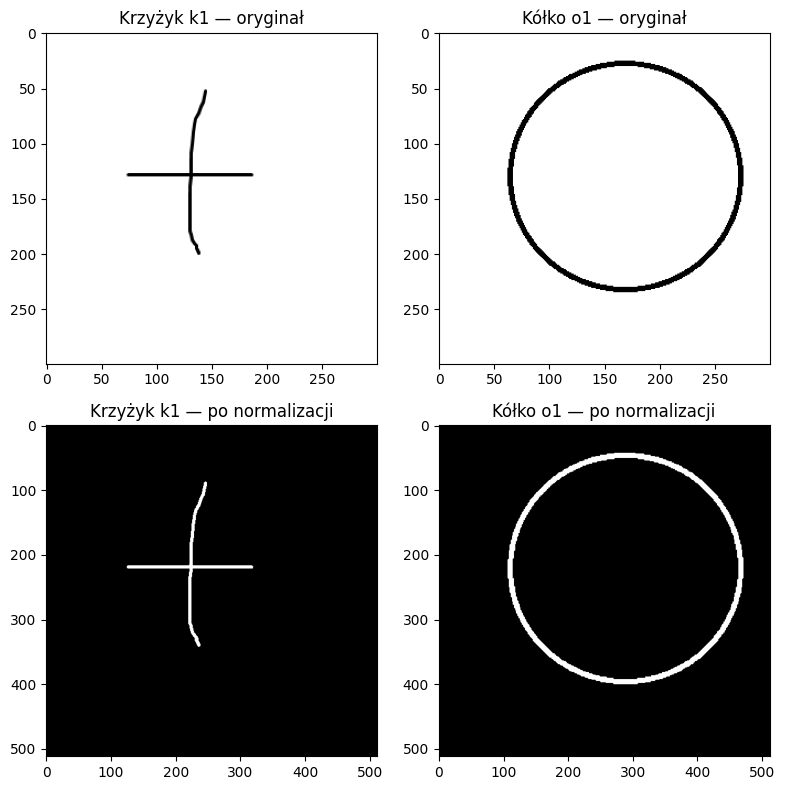

Liczba białych pikseli k1: 2273
Liczba białych pikseli o1: 9355


In [5]:
def Normalize(img, destSize=512, threshold=127):
    """
    Normalizuje obraz:
      1. Skaluje do destSize × destSize
      2. Konwertuje do skali szarości
      3. Binaryzuje progiem threshold
      4. Odwraca kolory (symbol biały na czarnym tle)
    """
    ret = cv.resize(img, (destSize, destSize))
    ret = cv.cvtColor(ret, cv.COLOR_BGR2GRAY)
    _, ret = cv.threshold(ret, threshold, 255, cv.THRESH_BINARY)
    ret = cv.bitwise_not(ret)
    return ret

# Wizualne porównanie: oryginalny vs znormalizowany (przykład dla k1 i o1)
fig, axes = pl.subplots(2, 2, figsize=(8, 8))
examples = [("Krzyżyk k1", train_k[0]), ("Kółko o1", train_o[0])]

for col, (title, img) in enumerate(examples):
    axes[0, col].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    axes[0, col].set_title(f"{title} — oryginał")
    axes[0, col].axis('on')

    norm = Normalize(img)
    # Normalize zwraca obraz jednokanałowy — konwertuj do BGR dla PlotImageList
    norm_bgr = cv.cvtColor(norm, cv.COLOR_GRAY2BGR)
    axes[1, col].imshow(cv.cvtColor(norm_bgr, cv.COLOR_BGR2RGB), cmap='gray')
    axes[1, col].set_title(f"{title} — po normalizacji")
    axes[1, col].axis('on')

pl.tight_layout()
pl.show()

print(f"Liczba białych pikseli k1: {Normalize(train_k[0]).sum() // 255}")
print(f"Liczba białych pikseli o1: {Normalize(train_o[0]).sum() // 255}")

## 5. Filtry krawędziowe — teoria i definicja

### Co to jest konwolucja?

Konwolucja to operacja matematyczna, w której **przesuwamy małą macierz (filtr/jądro)** po obrazie i w każdym miejscu obliczamy sumę ważoną wartości pikseli:

$$(I * K)(x, y) = \sum_{i=-1}^{1} \sum_{j=-1}^{1} I(x+i,\; y+j) \cdot K(i,j)$$

Funkcja `cv2.filter2D(src, ddepth=-1, kernel=K)` wykonuje tę operację dla każdego piksela obrazu.

### Dlaczego filtry krawędziowe?

Filtry krawędziowe wykrywają **gwałtowne zmiany jasności** — czyli krawędzie. Każdy z czterech filtrów jest wrażliwy na inny **kierunek krawędzi**:

| Filtr | Kierunek czułości | Opis |
|---|---|---|
| F1 — pionowy | ↕ | Wykrywa pionowe krawędzie |
| F2 — ukośny ↗ | ↗↙ | Wykrywa krawędzie skośne (prawy górny) |
| F3 — poziomy | ↔ | Wykrywa poziome krawędzie |
| F4 — ukośny ↖ | ↖↘ | Wykrywa krawędzie skośne (lewy górny) |

### Intuicja klasyfikacji

- **Krzyżyk** ma linie ukośne → silna odpowiedź na F2 i F4, słabsza na F1 i F3 → **wysoka wariancja**
- **Kółko** ma okrągłe krawędzie → podobna odpowiedź na wszystkie filtry → **niska wariancja**

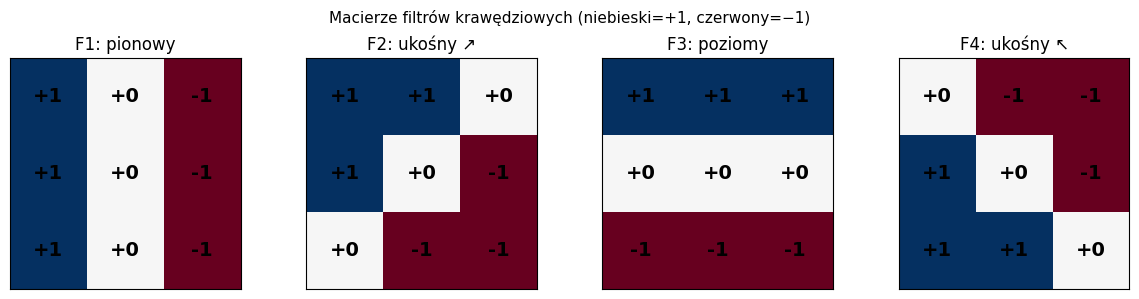

In [6]:
# Definicja czterech filtrów krawędziowych 3×3
filters = [
    np.array([[ 1,  0, -1],
              [ 1,  0, -1],
              [ 1,  0, -1]], dtype=np.float32),   # F1: pionowy

    np.array([[ 1,  1,  0],
              [ 1,  0, -1],
              [ 0, -1, -1]], dtype=np.float32),   # F2: ukośny ↗

    np.array([[ 1,  1,  1],
              [ 0,  0,  0],
              [-1, -1, -1]], dtype=np.float32),   # F3: poziomy

    np.array([[ 0, -1, -1],
              [ 1,  0, -1],
              [ 1,  1,  0]], dtype=np.float32),   # F4: ukośny ↖
]

filter_names = ["F1: pionowy", "F2: ukośny ↗", "F3: poziomy", "F4: ukośny ↖"]

# Wizualizacja filtrów jako macierzy z kolorami
fig, axes = pl.subplots(1, 4, figsize=(12, 3))
for i, (f, name) in enumerate(zip(filters, filter_names)):
    im = axes[i].imshow(f, cmap='RdBu', vmin=-1, vmax=1)
    axes[i].set_title(name)
    # Wyświetl wartości w komórkach
    for r in range(3):
        for c in range(3):
            axes[i].text(c, r, f"{int(f[r, c]):+d}",
                         ha='center', va='center', fontsize=14, fontweight='bold')
    axes[i].set_xticks([])
    axes[i].set_yticks([])

pl.suptitle("Macierze filtrów krawędziowych (niebieski=+1, czerwony=−1)", fontsize=11)
pl.tight_layout()
pl.show()

## 6. Zastosowanie filtrów i analiza wyników

### Funkcja `Filtering()`

Dla każdego obrazu z listy:
1. Normalizuje obraz → `ref`
2. Liczy białe piksele obrazu referencyjnego: `refVal = ref.sum() / 255`
3. Dla każdego z 4 filtrów: wykonuje konwolucję `cv2.filter2D()` i oblicza **współczynnik** $v$:

$$v = \frac{\sum_{i,j} I_{\text{filtr}}(i,j) / 255}{\sum_{i,j} I_{\text{ref}}(i,j) / 255}$$

Współczynnik $v$ mówi: **jaka część pikseli "przeżyła" po przefiltrowaniu** względem obrazu referencyjnego.

Wynik: lista naprzemiennych elementów `[obraz_ref, obraz_f1, obraz_f2, obraz_f3, obraz_f4, obraz_ref2, ...]`

In [ ]:
def Filtering(imgList, filterList):
    """
    Dla każdego obrazu: normalizuje, następnie stosuje każdy filtr.
    Zwraca:
      filtered - lista obrazów [ref, f1, f2, f3, f4, ref2, f1_2, ...]
      vals     - wartości [liczba_pikseli_ref, v_f1, v_f2, v_f3, v_f4, ...]
    """
    filtered = []
    vals = []
    for train in imgList:
        ref = Normalize(train)
        refVal = ref.sum() / 255          # liczba białych pikseli oryginału
        filtered.append(ref)
        vals.append(refVal)
        for filt in filterList:
            fimg = cv.filter2D(src=ref, ddepth=-1, kernel=filt)
            filtered.append(fimg)
            vals.append(f"{(fimg.sum() / 255 / refVal):.5}")
    return filtered, vals


filtered_k, vals_k = Filtering(train_k, filters)
filtered_o, vals_o = Filtering(train_o, filters)

In [ ]:
# Wyświetlenie wyników dla krzyżyków: kolumny = [oryginał, F1, F2, F3, F4]
print("=== Wyniki filtrowania — Krzyżyki ===")
print("Tytuły kolumn: [ref_piksele, v_F1, v_F2, v_F3, v_F4] dla każdego obrazu")
print(vals_k)
PlotImageList(
    [cv.cvtColor(img, cv.COLOR_GRAY2BGR) if len(img.shape) == 2 else img
     for img in filtered_k],
    limit=5, titles=[str(v) for v in vals_k], figsize=(16, 14)
)

=== Wyniki filtrowania — Kółka ===


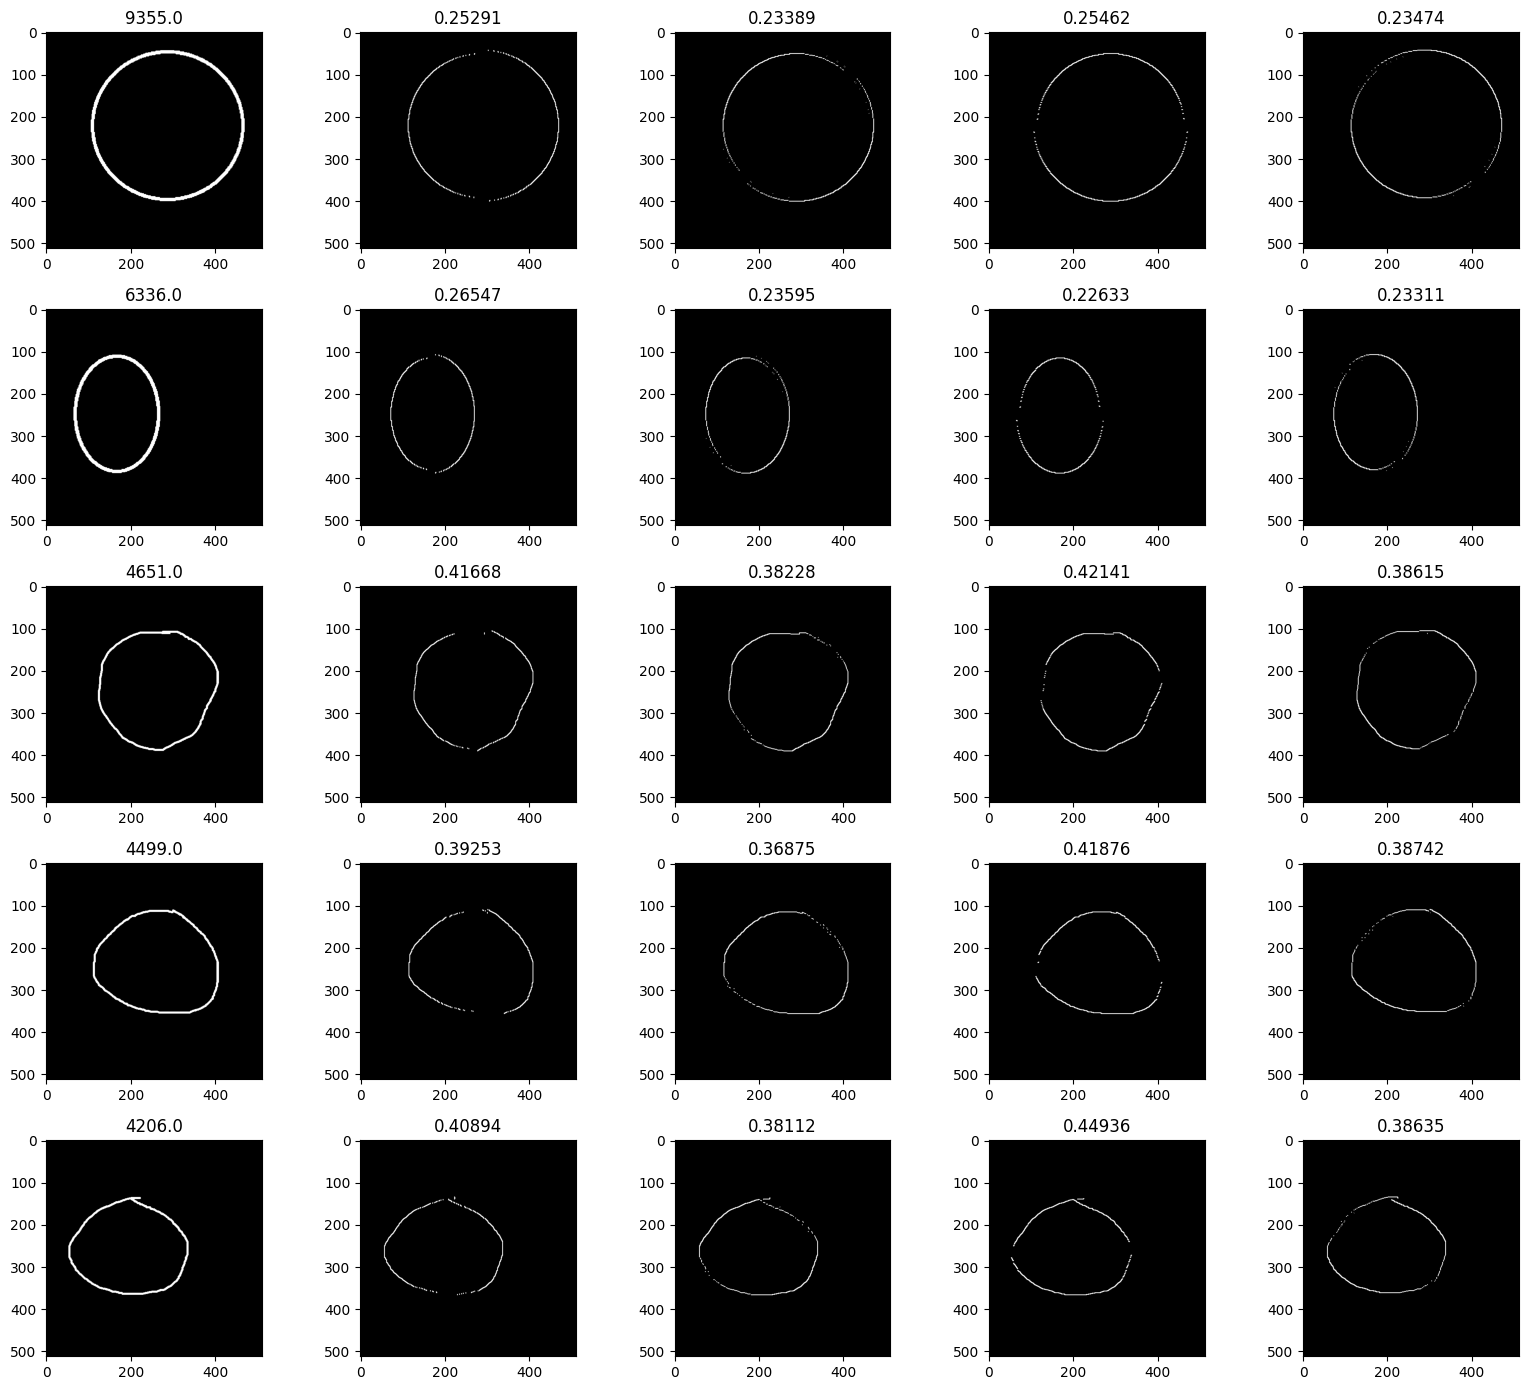

In [ ]:
# Wyświetlenie wyników dla kółek: kolumny = [oryginał, F1, F2, F3, F4]
print("=== Wyniki filtrowania — Kółka ===")
print("Tytuły kolumn: [ref_piksele, v_F1, v_F2, v_F3, v_F4] dla każdego obrazu")
print(vals_o)
PlotImageList(
    [cv.cvtColor(img, cv.COLOR_GRAY2BGR) if len(img.shape) == 2 else img
     for img in filtered_o],
    limit=5, titles=[str(v) for v in vals_o], figsize=(16, 14)
)

## 7. Obliczanie średniej wariancji dla każdej klasy

### Dlaczego wariancja?

Dla każdego obrazu mamy 4 wartości $v$ (odpowiedzi na 4 filtry). Wariancja tych czterech liczb mówi nam, **jak bardzo różnią się odpowiedzi na poszczególne filtry**:

$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (v_i - \bar{v})^2$$

- **Krzyżyk**: linie ukośne powodują, że filtry F2 i F4 dają wysokie wartości, a F1 i F3 niskie → **wysoka wariancja**
- **Kółko**: okrąg reaguje równomiernie na wszystkie kierunki → **niska wariancja**

### Funkcja `MeanVar()`

Odrzuca co 5. element (wartość referencyjną `refVal`), układa pozostałe wartości w macierz `N×4`, oblicza wariancję dla każdego wiersza, a następnie uśrednia po wszystkich obrazach klasy.

In [ ]:
def MeanVar(vals, nFilters=4):
    """
    Oblicza średnią wariancję odpowiedzi na filtry.
    - Pomija co (nFilters+1)-ty element (wartość referencyjną)
    - Układa pozostałe w macierz [n_obrazów × nFilters]
    - Oblicza wariancję dla każdego obrazu i zwraca średnią
    """
    # Odrzucenie wartości referencyjnych (co 5. element: indeksy 0, 5, 10, ...)
    only_filter_vals = [float(v) for i, v in enumerate(vals) if i % (nFilters + 1) != 0]

    # Macierz: każdy wiersz = [v_F1, v_F2, v_F3, v_F4] dla jednego obrazu
    matrix = np.reshape(only_filter_vals, (-1, nFilters))

    print("Macierz współczynników [v_F1, v_F2, v_F3, v_F4] dla każdego obrazu:")
    header = "  Obraz  |  F1-pion  |  F2-ukos↗ |  F3-poziom| F4-ukos↖  | Wariancja"
    print(header)
    print("-" * len(header))
    row_vars = []
    for i, row in enumerate(matrix):
        var = row.var()
        row_vars.append(var)
        print(f"  [{i+1}]    |  {row[0]:.5f}  |  {row[1]:.5f}  |  {row[2]:.5f}  |  {row[3]:.5f}  |  {var:.6f}")

    mean_var = np.mean(row_vars)
    print(f"\nŚrednia wariancja: {mean_var:.5f}")
    return mean_var

print("=" * 70)
print("KRZYŻYKI")
print("=" * 70)
mv_k = MeanVar(vals_k)

print()
print("=" * 70)
print("KÓŁKA")
print("=" * 70)
mv_o = MeanVar(vals_o)

## 8. Klasyfikacja — próg decyzyjny

### Podsumowanie wyników

Obliczone średnie wariancje tworzą **metrykę klasyfikacji**:
- Klasa z **wyższą wariancją** → **krzyżyk**
- Klasa z **niższą wariancją** → **kółko**

### Klasyfikacja nowego obrazu

Aby sklasyfikować nowy obraz, wystarczy:
1. Znormalizować obraz
2. Zastosować 4 filtry
3. Obliczyć wariancję 4 współczynników $v$
4. Porównać z progiem $T$ obliczonym jako średnia obu klas:

$$T = \frac{\sigma^2_{\text{krzyżyk}} + \sigma^2_{\text{kółko}}}{2}$$

$$\text{klasa} = \begin{cases} \text{krzyżyk} & \text{jeśli } \sigma^2 > T \\ \text{kółko} & \text{jeśli } \sigma^2 \leq T \end{cases}$$

In [ ]:
def ClassifyImage(img, filterList, threshold):
    """
    Klasyfikuje pojedynczy obraz jako 'krzyżyk' lub 'kółko'
    na podstawie wariancji odpowiedzi na filtry krawędziowe.
    """
    ref = Normalize(img)
    refVal = ref.sum() / 255
    filter_responses = []
    for filt in filterList:
        fimg = cv.filter2D(src=ref, ddepth=-1, kernel=filt)
        filter_responses.append(fimg.sum() / 255 / refVal)
    variance = np.array(filter_responses).var()
    label = "krzyżyk (X)" if variance > threshold else "kółko (O)"
    return label, variance, filter_responses

# Obliczenie progu decyzyjnego
threshold = (mv_k + mv_o) / 2
print(f"Średnia wariancja dla krzyżyków: {mv_k:.5f}")
print(f"Średnia wariancja dla kółek:     {mv_o:.5f}")
print(f"Próg decyzyjny T:                {threshold:.5f}")
print()

# Weryfikacja klasyfikatora na danych treningowych
print("Klasyfikacja obrazów treningowych:")
print(f"{'Obraz':<12} {'Wariancja':<14} {'Predykcja':<15} {'Oczekiwana'}")
print("-" * 56)
for i, img in enumerate(train_k):
    label, var, _ = ClassifyImage(img, filters, threshold)
    ok = "✓" if "krzyżyk" in label else "✗"
    print(f"  k{i+1}         {var:.5f}       {label:<15} krzyżyk (X)  {ok}")

for i, img in enumerate(train_o):
    label, var, _ = ClassifyImage(img, filters, threshold)
    ok = "✓" if "kółko" in label else "✗"
    print(f"  o{i+1}         {var:.5f}       {label:<15} kółko (O)    {ok}")

In [ ]:
# Wizualizacja wariancji jako wykres słupkowy
all_images = train_k + train_o
all_labels = [f"k{i+1}" for i in range(len(train_k))] + [f"o{i+1}" for i in range(len(train_o))]
all_vars = [ClassifyImage(img, filters, threshold)[1] for img in all_images]
colors = ['steelblue'] * len(train_k) + ['tomato'] * len(train_o)

fig, ax = pl.subplots(figsize=(10, 4))
bars = ax.bar(all_labels, all_vars, color=colors)
ax.axhline(y=threshold, color='black', linestyle='--', linewidth=1.5, label=f"Próg T = {threshold:.4f}")
ax.set_ylabel("Wariancja odpowiedzi na filtry")
ax.set_title("Wariancja jako cecha klasyfikacyjna\n(niebieski = krzyżyk, czerwony = kółko)")
ax.legend()
pl.tight_layout()
pl.show()

## Podsumowanie

W tym notatniku pokazaliśmy prostą metodę rozpoznawania symboli **bez uczenia maszynowego**:

1. **Normalizacja** — ujednolicenie rozmiaru, binaryzacja, inwersja kolorów.
2. **Filtry krawędziowe** — 4 macierze 3×3 wykrywające krawędzie w 4 kierunkach.
3. **Konwolucja** (`cv2.filter2D`) — zastosowanie filtrów do znormalizowanego obrazu.
4. **Współczynnik** $v$ — stosunek białych pikseli po filtracji do oryginału.
5. **Wariancja** 4 współczynników — miara asymetrii reakcji na filtry kierunkowe.
6. **Próg decyzyjny** — wartość pośrednia między średnimi wariancjami obu klas.

### Zalety metody
- Bardzo szybka (brak treningu sieci neuronowej)
- Interpretowalność — wiadomo, co i dlaczego jest mierzone
- Działa dobrze dla prostych, wyraźnych symboli

### Ograniczenia
- Wrażliwa na obrót symbolu
- Wymaga czystego, zbinaryzowanego obrazu
- Nie skaluje się na wiele skomplikowanych klas